In [1]:
import polars as pl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
import plotly.express as px
from math import pi
sns.set_theme(style='ticks')

In [2]:
study_metadata = pl.read_csv('data/hmp2_metadata_2018-08-20.csv', schema_overrides={'External ID': pl.String}).filter(pl.col('data_type') == 'metagenomics')
study_metadata = study_metadata.select(['External ID', 'Age at diagnosis', 'consent_age', 'sex', 'diagnosis']).with_columns(pl.col("External ID").str.split("_").list.get(0).alias("External ID"))
study_metadata

External ID,Age at diagnosis,consent_age,sex,diagnosis
str,f64,f64,str,str
"""CSM5FZ3N""",28.0,43.0,"""Female""","""CD"""
"""CSM5FZ3R""",28.0,43.0,"""Female""","""CD"""
"""CSM5YRY7""",28.0,43.0,"""Female""","""CD"""
"""CSM5FZ3V""",28.0,43.0,"""Female""","""CD"""
"""CSM5FZ4C""",28.0,43.0,"""Female""","""CD"""
…,…,…,…,…
"""PSMA26A1""",8.0,16.0,"""Female""","""UC"""
"""PSMA26A3""",8.0,16.0,"""Female""","""UC"""
"""PSMB4MC1""",8.0,16.0,"""Female""","""UC"""


In [3]:
ena_metadata = pl.read_csv('data/filereport_read_run_PRJNA398089.tsv', separator='\t').select(['sample_accession', 'experiment_alias'])
ena_metadata = ena_metadata.with_columns(pl.col("experiment_alias").str.split("_").list.get(0).alias("experiment_alias")).join(study_metadata, left_on='experiment_alias', right_on='External ID')

In [4]:
genome_metadata = pl.read_csv('https://swifter.embl.de/~fullam/spire/metadata/spire_v1_genome_metadata.tsv.gz', separator='\t')
genome_metadata = genome_metadata.select(['genome_id', 'domain', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'derived_from_sample', 'n_contigs'])
genome_metadata

genome_id,domain,phylum,class,order,family,genus,species,derived_from_sample,n_contigs
str,str,str,str,str,str,str,str,str,f64
"""spire_mag_00000001""","""Bacteria""","""Actinobacteriota""","""Actinomycetia""","""Actinomycetales""","""Microbacteriaceae""","""Pontimonas""","""Pontimonas sp001438965""","""SAMEA104408696""",153.0
"""spire_mag_00000003""","""Bacteria""","""Proteobacteria""","""Alphaproteobacteria""","""Pelagibacterales""","""Pelagibacteraceae""","""Pelagibacter""","""Pelagibacter sp013204495""","""SAMEA104408696""",124.0
"""spire_mag_00000006""","""Bacteria""","""Chloroflexota""","""Dehalococcoidia""","""UBA1151""","""UBA1328""","""UBA1328""",null,"""SAMEA104408696""",317.0
"""spire_mag_00000007""","""Bacteria""","""Planctomycetota""","""Planctomycetia""","""Planctomycetales""","""Planctomycetaceae""",null,null,"""SAMEA104408696""",813.0
"""spire_mag_00000008""","""Bacteria""","""Planctomycetota""","""UBA8108""","""UBA1146""","""UBA1146""","""JAFMMO01""",null,"""SAMEA104408696""",704.0
…,…,…,…,…,…,…,…,…,…
"""spire_mag_03023324""","""Bacteria""","""Firmicutes_A""","""Clostridia""","""Lachnospirales""","""Lachnospiraceae""","""Clostridium_Q""","""Clostridium_Q fessum""","""SAMEA14100596""",127.0
"""spire_mag_03023325""","""Bacteria""","""Firmicutes_A""","""Clostridia""","""Oscillospirales""","""Oscillospiraceae""","""ER4""","""ER4 sp000765235""","""SAMEA14100468""",34.0
"""spire_mag_03023326""","""Bacteria""","""Firmicutes_A""","""Clostridia""","""Lachnospirales""","""Lachnospiraceae""","""Agathobacter""","""Agathobacter rectalis""","""SAMEA14101339""",181.0


In [5]:
genome_metadata = genome_metadata.join(ena_metadata, left_on='derived_from_sample', right_on='sample_accession')
genome_metadata

genome_id,domain,phylum,class,order,family,genus,species,derived_from_sample,n_contigs,experiment_alias,Age at diagnosis,consent_age,sex,diagnosis
str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str
"""spire_mag_00360916""","""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Escherichia""","""Escherichia coli""","""SAMN07521601""",595.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360924""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides uniformis""","""SAMN07521601""",67.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360925""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Phocaeicola""","""Phocaeicola vulgatus""","""SAMN07521601""",86.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360930""","""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Enterobacterales""","""Pasteurellaceae""","""Haemophilus_D""","""Haemophilus_D sp001815355""","""SAMN07521700""",316.0,"""HSM6XRS6""",15.0,15.0,"""Male""","""CD"""
"""spire_mag_00360931""","""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Burkholderiales""","""Burkholderiaceae""","""Sutterella""","""Sutterella wadsworthensis_A""","""SAMN07521700""",76.0,"""HSM6XRS6""",15.0,15.0,"""Male""","""CD"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""spire_mag_02048099""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides uniformis""","""SAMN07532854""",66.0,"""CSM9X215""",28.0,46.0,"""Female""","""UC"""
"""spire_mag_02048102""","""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides finegoldii""","""SAMN07532854""",166.0,"""CSM9X215""",28.0,46.0,"""Female""","""UC"""
"""spire_mag_02048110""","""Bacteria""","""Firmicutes_A""","""Clostridia""","""Lachnospirales""","""Lachnospiraceae""","""Agathobacter""","""Agathobacter faecis""","""SAMN07521692""",53.0,"""CSM67U9B""",30.0,37.0,"""Female""","""CD"""


In [6]:
scores = pl.read_csv('../results/combined_scores.tsv', separator='\t')
scores

taxon,et_score,ca_score,pb_score
str,f64,f64,f64
"""spire_mag_00375920""",-107.891143,-0.427444,-0.1
"""spire_mag_00362780""",138.657018,-0.105361,0.174603
"""spire_mag_00373296""",-325.408276,-0.461635,-0.12
"""spire_mag_00369020""",-33.080922,0.109199,0.103448
"""spire_mag_00366726""",-43.610401,-0.635989,-0.031746
…,…,…,…
"""spire_mag_00370395""",-163.742879,-1.158204,-0.210526
"""spire_mag_00363470""",-622.763848,-0.872733,-0.311475
"""spire_mag_00368645""",328.987187,1.08931,0.17757


In [7]:
joined = scores.join(genome_metadata, left_on='taxon', right_on='genome_id').with_columns(ca_score=pl.col('ca_score').clip(-2,4))
joined.describe()

statistic,taxon,et_score,ca_score,pb_score,domain,phylum,class,order,family,genus,species,derived_from_sample,n_contigs,experiment_alias,Age at diagnosis,consent_age,sex,diagnosis
str,str,f64,f64,f64,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str
"""count""","""7604""",7604.0,7604.0,7604.0,"""7604""","""7604""","""7604""","""7604""","""7604""","""7600""","""7560""","""7604""",7604.0,"""7604""",5104.0,7561.0,"""7604""","""7604"""
"""null_count""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""4""","""44""","""0""",0.0,"""0""",2500.0,43.0,"""0""","""0"""
"""mean""",null,53.337179,-0.252849,-0.006813,null,null,null,null,null,null,null,null,162.630852,null,22.101685,28.860204,null,null
"""std""",null,387.172878,0.743031,0.152646,null,null,null,null,null,null,null,null,128.083605,null,13.349566,18.613037,null,null
"""min""","""spire_mag_00360916""",-1958.431583,-1.680534,-0.6,"""Archaea""","""Actinobacteriota""","""Actinomycetia""","""Acholeplasmatales""","""Acidaminococcaceae""","""43-108""","""43-108 sp001915545""","""SAMN07509534""",4.0,"""CSM5FZ4M""",5.0,6.0,"""Female""","""CD"""
"""25%""",null,-107.893043,-0.757096,-0.106383,null,null,null,null,null,null,null,null,61.0,null,13.0,14.0,null,null
"""50%""",null,10.625212,-0.475424,0.0,null,null,null,null,null,null,null,null,124.0,null,19.0,23.0,null,null
"""75%""",null,188.209321,0.038715,0.09434,null,null,null,null,null,null,null,null,239.0,null,29.0,43.0,null,null
"""max""","""spire_mag_02048113""",2803.664823,4.0,0.714286,"""Bacteria""","""Verrucomicrobiota""","""Verrucomicrobiae""","""Verrucomicrobiales""","""Veillonellaceae""","""Zag111""","""Zag111 sp003258735""","""SAMN07549056""",1046.0,"""PSMB4MC7""",74.0,76.0,"""Male""","""nonIBD"""


In [8]:
top10_genus = joined.group_by('genus').len().sort(by='len', descending=True)[0:10]['genus'].to_list()

In [9]:
top10_species = joined.group_by('species').len().sort(by='len', descending=True)[0:10]['species'].to_list()

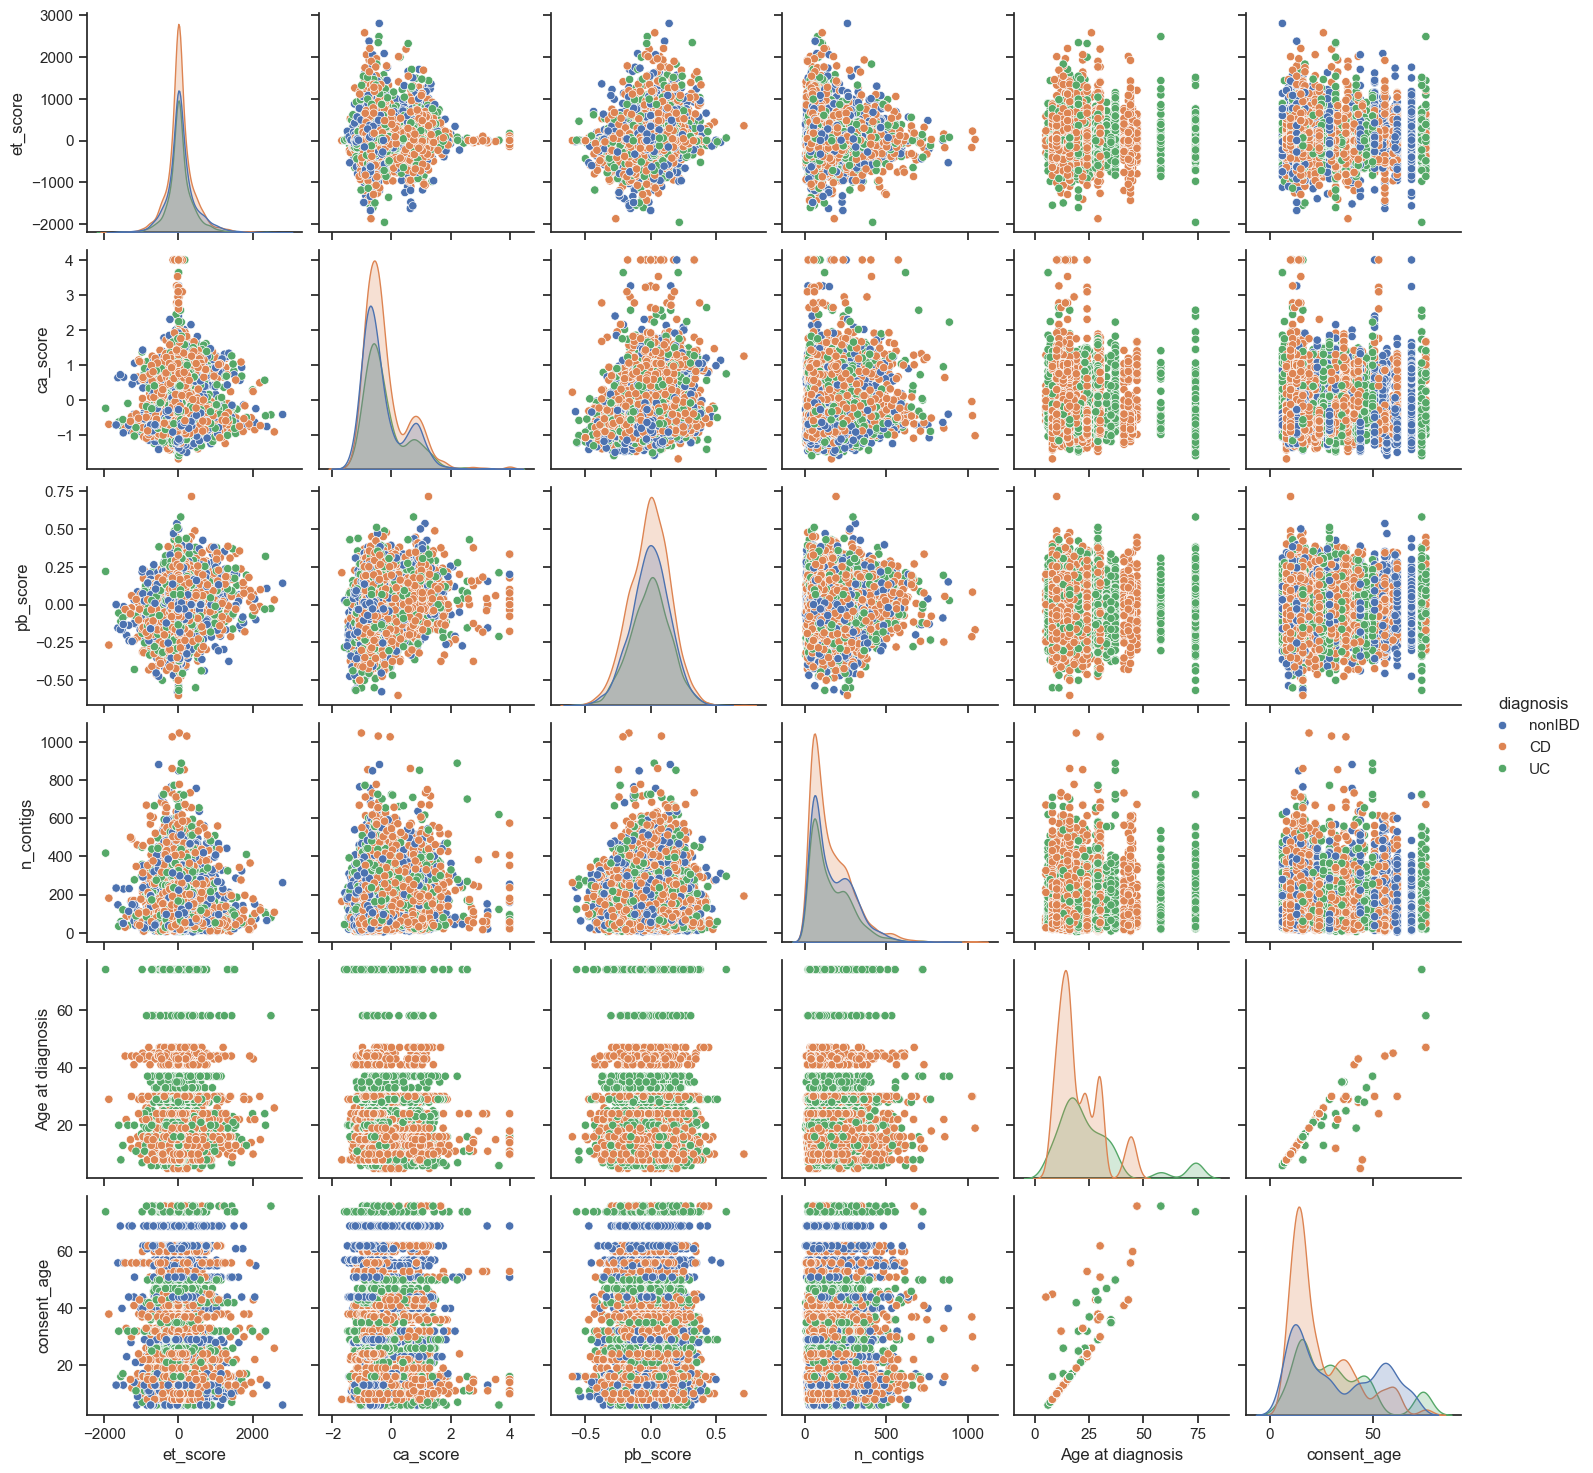

In [33]:
sns.pairplot(joined.to_pandas(),hue='diagnosis').savefig('figures/pairplot_scores.png')

# Scores in top-10 genera and species

## Exchange tendency

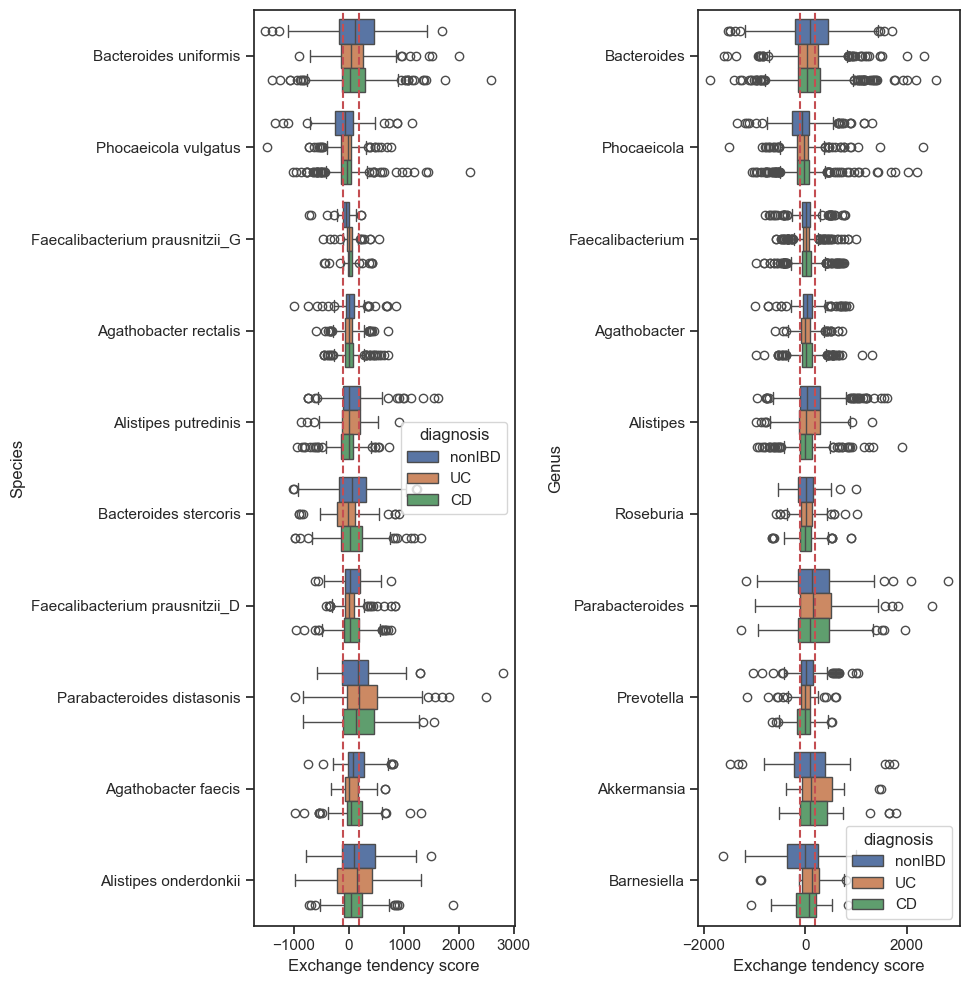

In [34]:
fig, axes = plt.subplots(1,2,figsize = (10,10))
sns.boxplot(data=joined.filter(pl.col('species').is_in(top10_species)).to_pandas(), x="et_score", y="species", hue='diagnosis', ax=axes[0])
axes[0].axvline(x=joined['et_score'].quantile(0.25), color='r', linestyle='--')
axes[0].axvline(x=joined['et_score'].quantile(0.75), color='r', linestyle='--')
axes[0].set(ylabel="Species", xlabel="Exchange tendency score")

sns.boxplot(data=joined.filter(pl.col('genus').is_in(top10_genus)).to_pandas(), x="et_score", y="genus", hue='diagnosis', ax=axes[1])
axes[1].set(ylabel="Genus", xlabel="Exchange tendency score")
axes[1].axvline(x=joined['et_score'].quantile(0.25), color='r', linestyle='--')
axes[1].axvline(x=joined['et_score'].quantile(0.75), color='r', linestyle='--')


plt.tight_layout()
plt.savefig("figures/boxplot_et.png")

/home/alexandre/miniconda3/envs/analysis/lib/python3.14/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/alexandre/miniconda3/envs/analysis/lib/python3.14/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


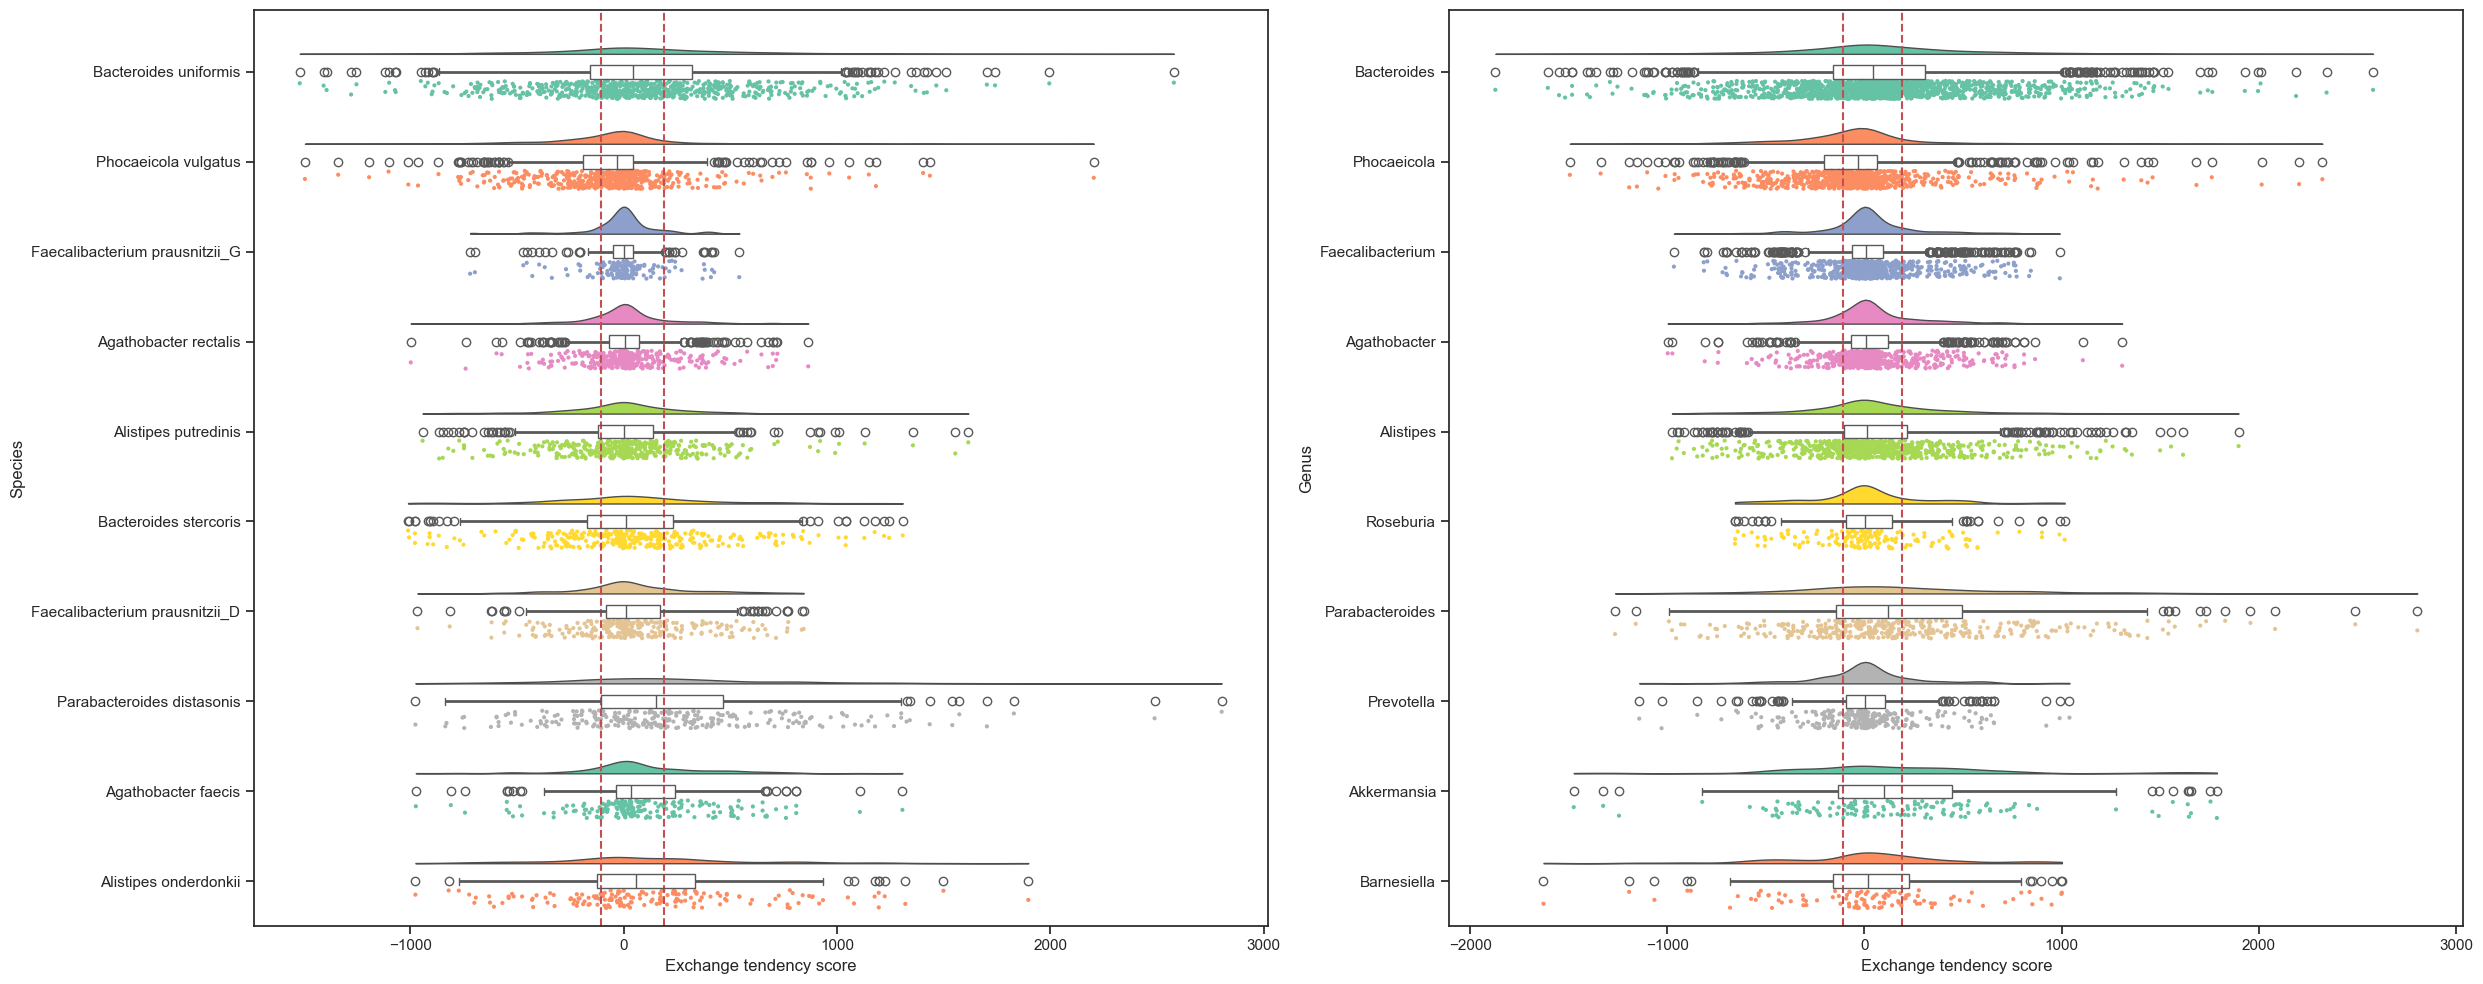

In [35]:
fig, axes = plt.subplots(1,2,figsize = (25,10))
pt.RainCloud(x="species", y="et_score", data=joined.filter(pl.col('species').is_in(top10_species)).to_pandas(), 
                 palette="Set2", bw=0.2, width_viol=0.6, 
                 orient="h", move=0.2, ax=axes[0])
axes[0].axvline(x=joined['et_score'].quantile(0.25), color='r', linestyle='--')
axes[0].axvline(x=joined['et_score'].quantile(0.75), color='r', linestyle='--')
axes[0].set(ylabel="Species", xlabel="Exchange tendency score")

pt.RainCloud(x="genus", y="et_score", data=joined.filter(pl.col('genus').is_in(top10_genus)).to_pandas(), 
                 palette="Set2", bw=0.2, width_viol=0.6, 
                 orient="h", move=0.2, ax=axes[1])
axes[1].axvline(x=joined['et_score'].quantile(0.25), color='r', linestyle='--')
axes[1].axvline(x=joined['et_score'].quantile(0.75), color='r', linestyle='--')
axes[1].set(ylabel="Genus", xlabel="Exchange tendency score")

plt.tight_layout()
plt.savefig("figures/raincloud_et.png")

## Cooperative alignment

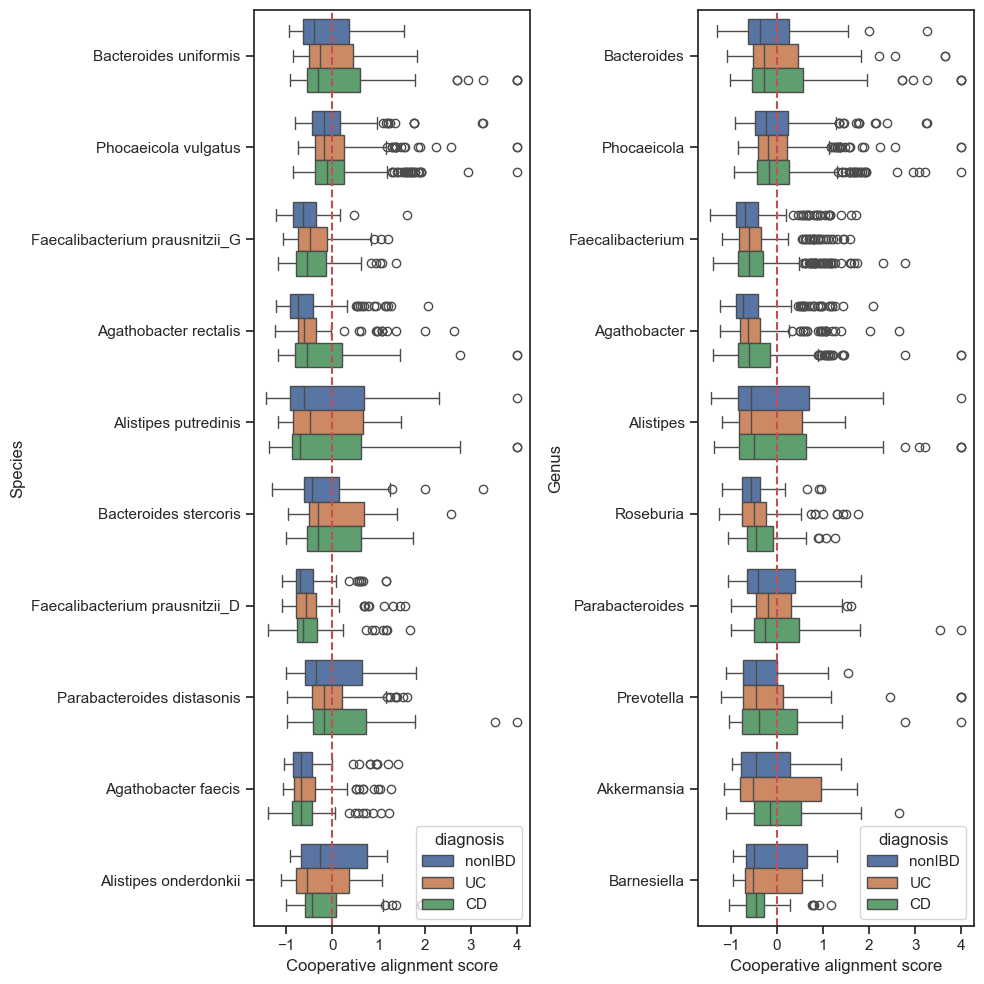

In [36]:
fig, axes = plt.subplots(1,2,figsize = (10,10))
sns.boxplot(data=joined.filter(pl.col('species').is_in(top10_species)).to_pandas(), x="ca_score", y="species", hue='diagnosis', ax=axes[0])
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].set(ylabel="Species", xlabel="Cooperative alignment score")

sns.boxplot(data=joined.filter(pl.col('genus').is_in(top10_genus)).to_pandas(), x="ca_score", y="genus", hue='diagnosis', ax=axes[1])
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set(ylabel="Genus", xlabel="Cooperative alignment score")

plt.tight_layout()
plt.savefig('figures/boxplot_ca.png')

/home/alexandre/miniconda3/envs/analysis/lib/python3.14/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/alexandre/miniconda3/envs/analysis/lib/python3.14/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


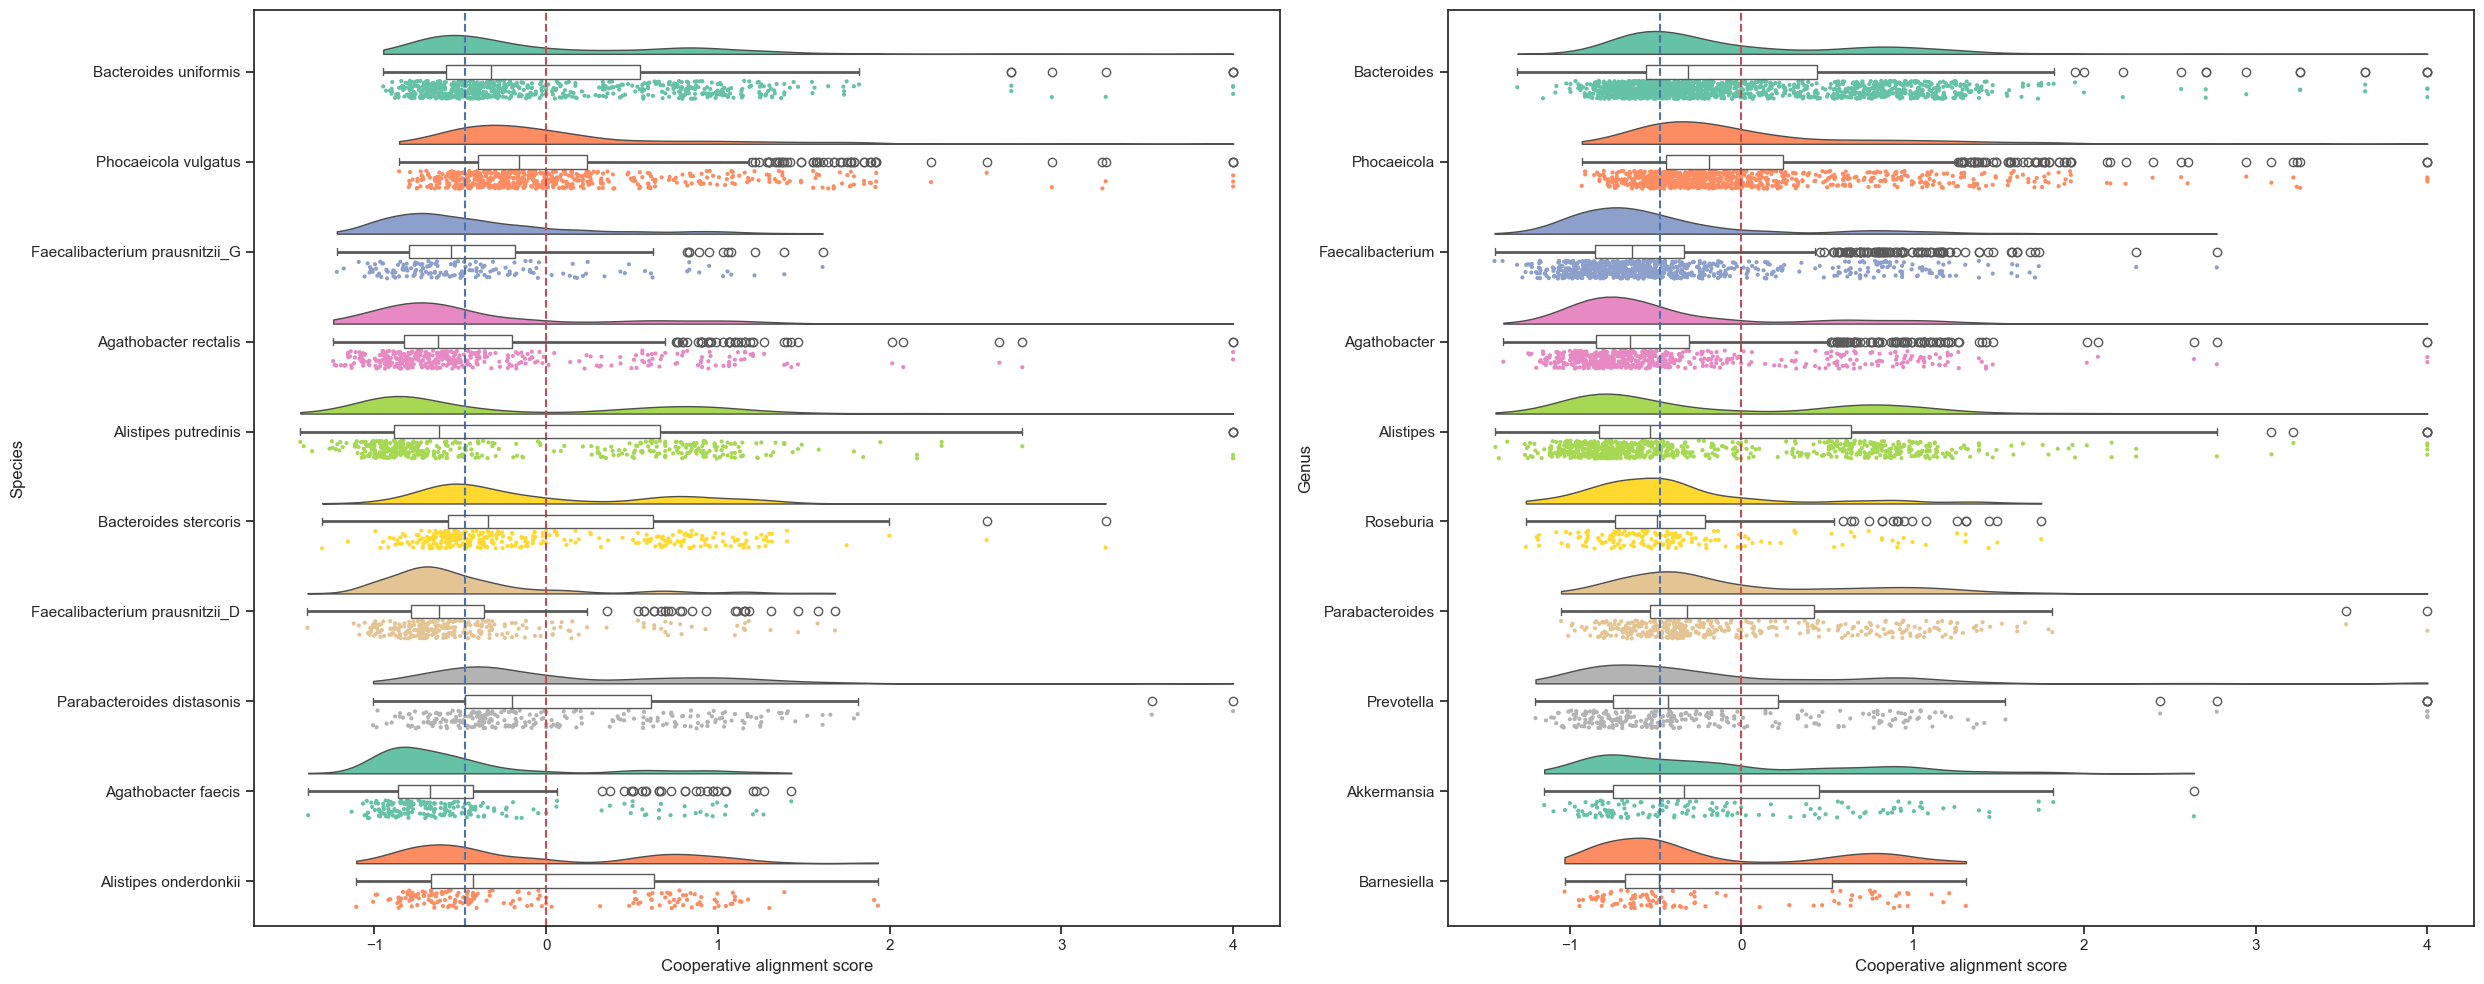

In [37]:
fig, axes = plt.subplots(1,2,figsize = (25,10))
pt.RainCloud(x="species", y="ca_score", data=joined.filter(pl.col('species').is_in(top10_species)).filter(pl.col('ca_score') != np.inf).to_pandas(), 
                 palette="Set2", bw=0.2, width_viol=0.6, 
                 orient="h", move=0.2, ax=axes[0])
axes[0].axvline(x=joined['ca_score'].quantile(0.5), color='b', linestyle='--')
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].set(ylabel="Species", xlabel="Cooperative alignment score")
pt.RainCloud(x="genus", y="ca_score", data=joined.filter(pl.col('genus').is_in(top10_genus)).filter(pl.col('ca_score') != np.inf).to_pandas(), 
                 palette="Set2", bw=0.2, width_viol=0.6, 
                 orient="h", move=0.2, ax=axes[1])
axes[1].axvline(x=joined['ca_score'].quantile(0.5), color='b', linestyle='--')
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set(ylabel="Genus", xlabel="Cooperative alignment score")

plt.tight_layout()
plt.savefig('figures/raincloud_ca.png')

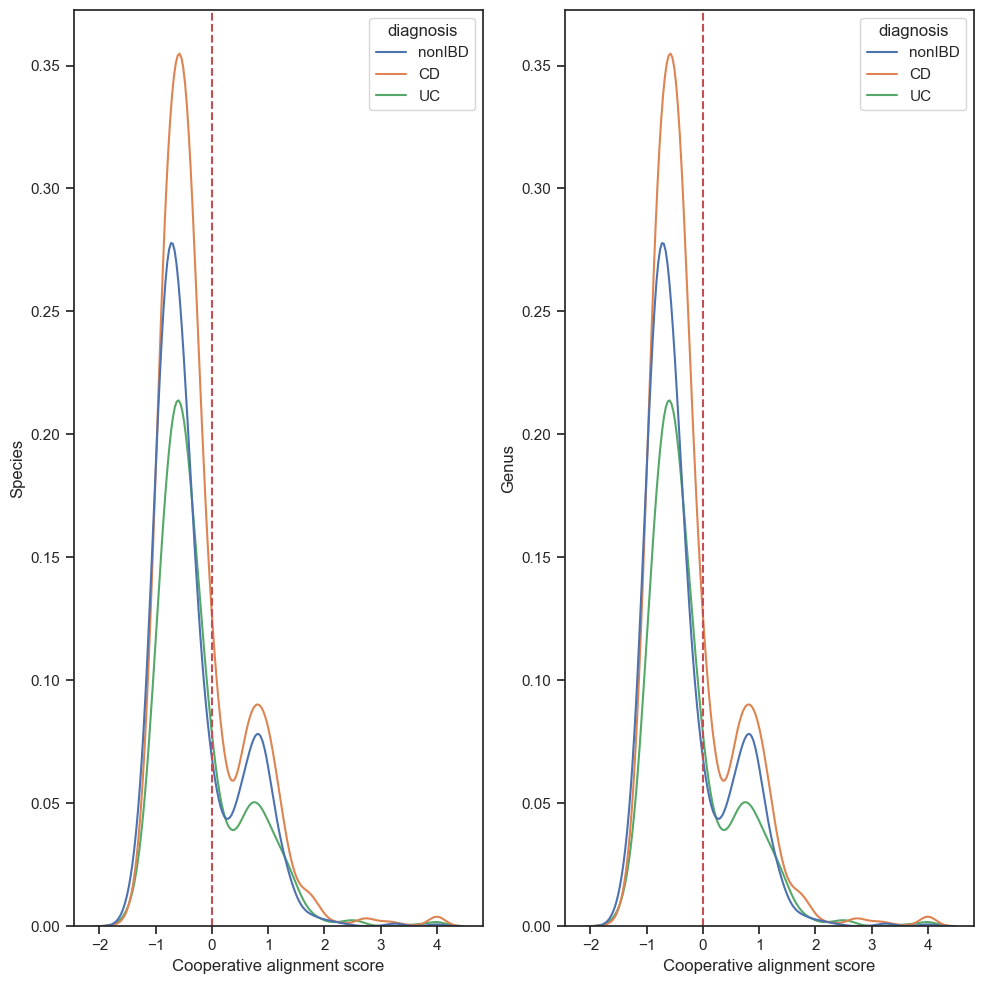

In [38]:
fig, axes = plt.subplots(1,2,figsize = (10,10))
sns.kdeplot(data=joined.to_pandas(), x="ca_score", hue='diagnosis', ax=axes[0])
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].set(ylabel="Species", xlabel="Cooperative alignment score")

sns.kdeplot(data=joined.to_pandas(), x="ca_score", hue='diagnosis', ax=axes[1])
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set(ylabel="Genus", xlabel="Cooperative alignment score")

plt.tight_layout()
plt.savefig('figures/kde_ca.png')

## Provisioning bias score

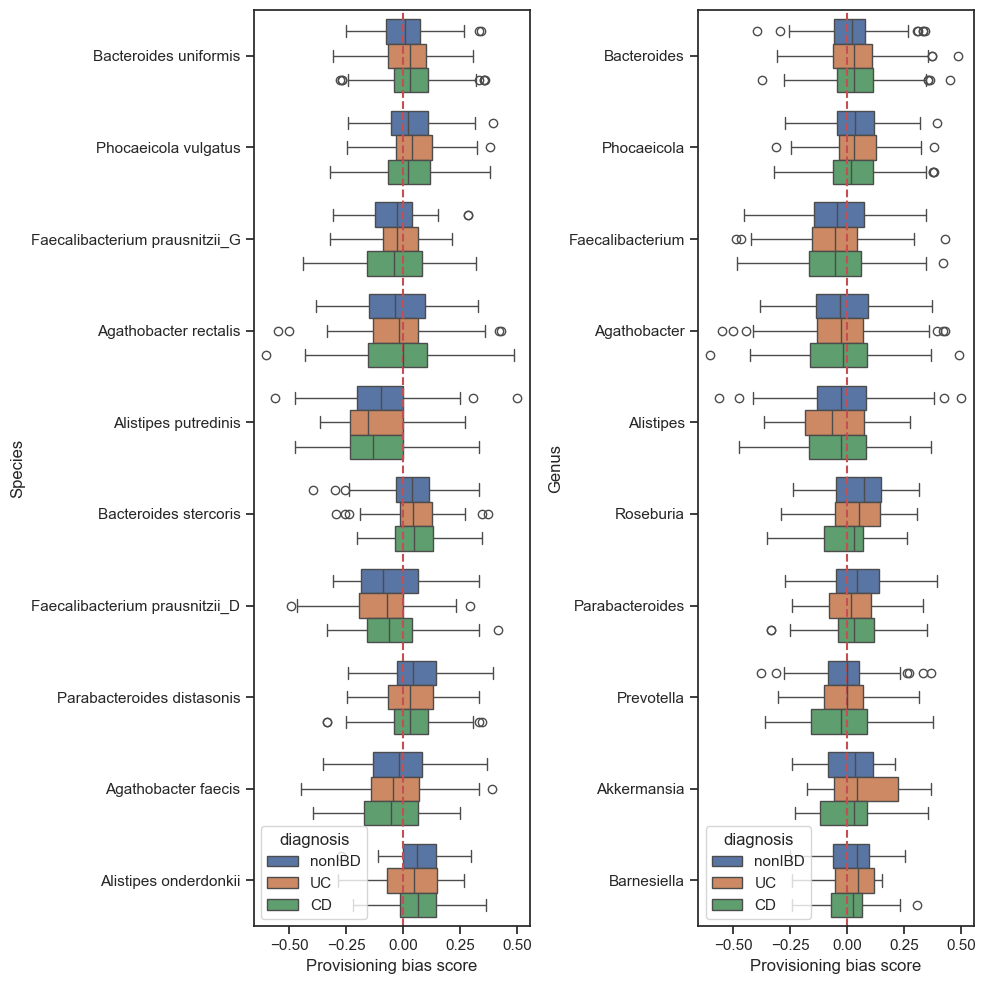

In [39]:
fig, axes = plt.subplots(1,2,figsize = (10,10))
sns.boxplot(data=joined.filter(pl.col('species').is_in(top10_species)).to_pandas(), x="pb_score", y="species", hue='diagnosis', ax=axes[0])
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].set(ylabel="Species", xlabel="Provisioning bias score")

sns.boxplot(data=joined.filter(pl.col('genus').is_in(top10_genus)).to_pandas(), x="pb_score", y="genus", hue='diagnosis', ax=axes[1])
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set(ylabel="Genus", xlabel="Provisioning bias score")

plt.tight_layout()
plt.savefig('figures/boxplot_pb.png')

/home/alexandre/miniconda3/envs/analysis/lib/python3.14/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/alexandre/miniconda3/envs/analysis/lib/python3.14/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


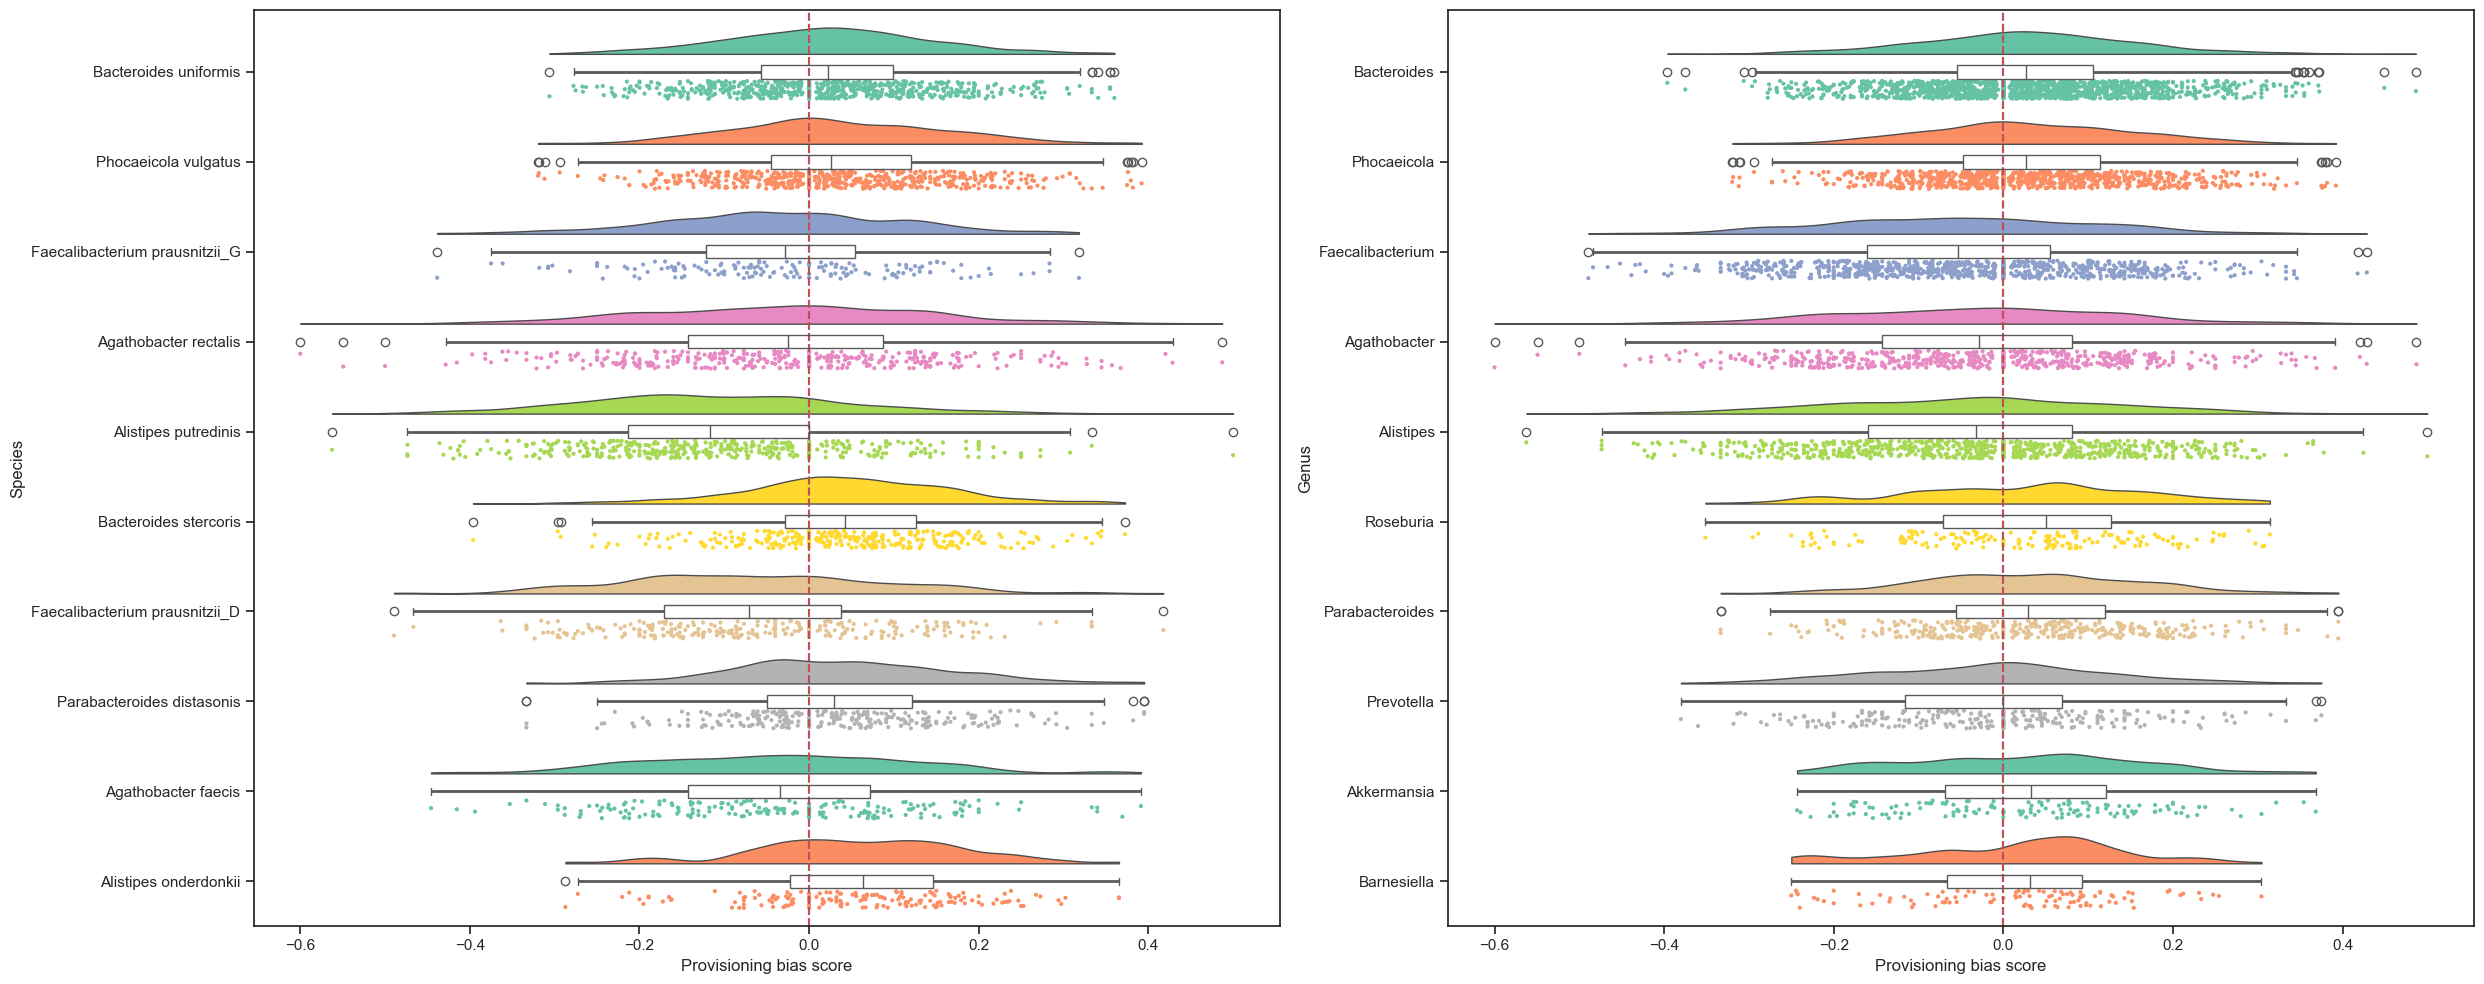

In [40]:
fig, axes = plt.subplots(1,2,figsize = (25,10))
pt.RainCloud(x="species", y="pb_score", data=joined.filter(pl.col('species').is_in(top10_species)).filter(pl.col('pb_score') != np.inf).to_pandas(), 
                 palette="Set2", bw=0.2, width_viol=0.6, 
                 orient="h", move=0.2, ax=axes[0])
axes[0].axvline(x=joined['pb_score'].quantile(0.5), color='b', linestyle='--')
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].set(ylabel="Species", xlabel="Provisioning bias score")
pt.RainCloud(x="genus", y="pb_score", data=joined.filter(pl.col('genus').is_in(top10_genus)).filter(pl.col('pb_score') != np.inf).to_pandas(), 
                 palette="Set2", bw=0.2, width_viol=0.6, 
                 orient="h", move=0.2, ax=axes[1])
axes[1].axvline(x=joined['pb_score'].quantile(0.5), color='b', linestyle='--')
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set(ylabel="Genus", xlabel="Provisioning bias score")

plt.tight_layout()
plt.savefig('figures/raincloud_pb.png')

# Combined scores

In [18]:
normalized = joined.with_columns(
    et_score = ((pl.col("et_score") - pl.col("et_score").mean()) / pl.col("et_score").std()),
    ca_score = ((pl.col("ca_score") - pl.col("ca_score").mean()) / pl.col("ca_score").std()),
    pb_score = ((pl.col("pb_score") - pl.col("pb_score").mean()) / pl.col("pb_score").std()),
    
)
normalized

taxon,et_score,ca_score,pb_score,domain,phylum,class,order,family,genus,species,derived_from_sample,n_contigs,experiment_alias,Age at diagnosis,consent_age,sex,diagnosis
str,f64,f64,f64,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str
"""spire_mag_00360916""",-0.576988,0.574945,-0.042714,"""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Escherichia""","""Escherichia coli""","""SAMN07521601""",595.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360924""",0.698211,-0.072037,-1.315032,"""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides uniformis""","""SAMN07521601""",67.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360925""",0.441312,0.482092,1.167684,"""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Phocaeicola""","""Phocaeicola vulgatus""","""SAMN07521601""",86.0,"""HSMA33SG""",null,14.0,"""Female""","""nonIBD"""
"""spire_mag_00360930""",-0.08954,-0.024261,-0.100946,"""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Enterobacterales""","""Pasteurellaceae""","""Haemophilus_D""","""Haemophilus_D sp001815355""","""SAMN07521700""",316.0,"""HSM6XRS6""",15.0,15.0,"""Male""","""CD"""
"""spire_mag_00360931""",0.761344,0.064673,-0.253144,"""Bacteria""","""Proteobacteria""","""Gammaproteobacteria""","""Burkholderiales""","""Burkholderiaceae""","""Sutterella""","""Sutterella wadsworthensis_A""","""SAMN07521700""",76.0,"""HSM6XRS6""",15.0,15.0,"""Male""","""CD"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""spire_mag_02048099""",0.006481,-0.096426,0.481376,"""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides uniformis""","""SAMN07532854""",66.0,"""CSM9X215""",28.0,46.0,"""Female""","""UC"""
"""spire_mag_02048102""",-0.151364,-0.112544,-0.828849,"""Bacteria""","""Bacteroidota""","""Bacteroidia""","""Bacteroidales""","""Bacteroidaceae""","""Bacteroides""","""Bacteroides finegoldii""","""SAMN07532854""",166.0,"""CSM9X215""",28.0,46.0,"""Female""","""UC"""
"""spire_mag_02048110""",0.314962,-0.450773,-1.503813,"""Bacteria""","""Firmicutes_A""","""Clostridia""","""Lachnospirales""","""Lachnospiraceae""","""Agathobacter""","""Agathobacter faecis""","""SAMN07521692""",53.0,"""CSM67U9B""",30.0,37.0,"""Female""","""CD"""


In [19]:
short = joined.select(['et_score', 'ca_score', 'pb_score', 'diagnosis', 'species'])
short
short.filter(pl.col('diagnosis') == 'UC').filter(pl.col('species').is_in(top10_species)).mean()

et_score,ca_score,pb_score,diagnosis,species
f64,f64,f64,str,str
45.078084,-0.132467,-0.000798,null,null


/tmp/ipykernel_14672/201739649.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_palette = plt.cm.get_cmap("Set2", len(df.index))


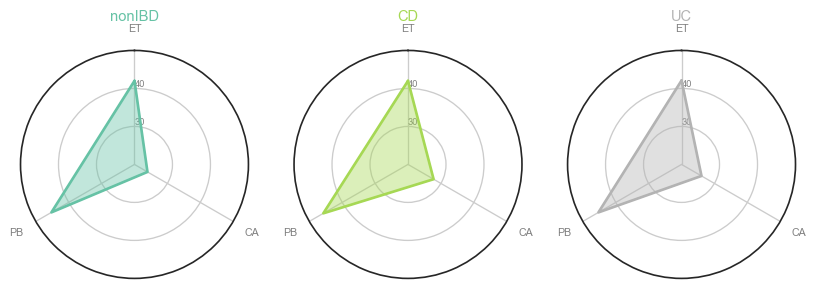

In [20]:
 
# Set data
df = pd.DataFrame({
'group': ['nonIBD', 'CD','UC'],
'ET': [42.004034, 42.004034, 42.092855],
'CA': [23.948854, 27.77522, 26.063343],
'PB': [45.237005, 45.742731, 45.255201],
})
 
# ------- PART 1: Define a function that do a plot for one line of the dataset!
 
def make_spider( row, title, color):

    # number of variable
    categories=list(df)[1:]
    N = len(categories)

    # What will be the angle of each axis in the plot? (we divide the plot / number of variable)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    # Initialise the spider plot
    ax = plt.subplot(1,3,row+1, polar=True, )

    # If you want the first axis to be on top:
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # Draw one axe per variable + add labels labels yet
    plt.xticks(angles[:-1], categories, color='grey', size=8)

    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([30,40], ["30", "40"], color="grey", size=7)
    plt.ylim(20,50)

    # Ind1
    values=df.loc[row].drop('group').values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.4)

    # Add a title
    plt.title(title, size=11, color=color, y=1.1)

    
# ------- PART 2: Apply the function to all individuals
# initialize the figure
my_dpi=96
plt.figure(figsize=(1000/my_dpi, 1000/my_dpi), dpi=my_dpi)
 
# Create a color palette:
my_palette = plt.cm.get_cmap("Set2", len(df.index))
 
# Loop to plot
for row in range(0, len(df.index)):
    make_spider( row=row, title=df['group'][row], color=my_palette(row))